# Mount Colab

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Installing PyTorch, TorchVision, and Torchaudio with CUDA 12.1 support

In [ ]:
# Install a specific version with CUDA 12.1 support
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121


Looking in indexes: https://download.pytorch.org/whl/cu121


In [ ]:
!pip install --upgrade torch


In [ ]:
import torch
print(torch.__version__)
print("CUDA Available:", torch.cuda.is_available())


2.5.1+cu121
CUDA Available: True


In [ ]:
import os
num_cores = os.cpu_count()
print("Number of CPU cores:", num_cores)


Number of CPU cores: 2


#Import libraries

In [ ]:
import os
import glob
import random
import numpy as np
import matplotlib.pyplot as plt

# PyTorch and Torch-related imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Scikit-learn imports
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
)

# Data preparation

In [ ]:
# Base path for data on Google Drive
base_path = '/content/drive/My Drive/MENG/Deep Learning/Project/Fixed_length_frame_processed'

# Paths for train, validation, and test features
TRAIN_PATHS = {
    'mfcc': os.path.join(base_path, 'Processed_train/processed_mfcc_train.npz'),
    'cqcc': os.path.join(base_path, 'Processed_train/processed_cqcc_train.npy'),
    'pitch': os.path.join(base_path, 'Processed_train/processed_pitch_train.npy'),
    'energy': os.path.join(base_path, 'Processed_train/processed_energy_train.npy'),
    'embedding': os.path.join(base_path, 'Processed_train/processed_embedding_train.npy')
}
VAL_PATHS = {
    'mfcc': os.path.join(base_path, 'Processed_val/processed_mfcc_val.npz'),
    'cqcc': os.path.join(base_path, 'Processed_val/processed_cqcc_val.npy'),
    'pitch': os.path.join(base_path, 'Processed_val/processed_pitch_val.npy'),
    'energy': os.path.join(base_path, 'Processed_val/processed_energy_val.npy'),
    'embedding': os.path.join(base_path, 'Processed_val/processed_embedding_val.npy')
}
TEST_PATHS = {
    'mfcc': os.path.join(base_path, 'Processed_test/processed_mfcc_test.npz'),
    'cqcc': os.path.join(base_path, 'Processed_test/processed_cqcc_test.npy'),
    'pitch': os.path.join(base_path, 'Processed_test/processed_pitch_test.npy'),
    'energy': os.path.join(base_path, 'Processed_test/processed_energy_test.npy'),
    'embedding': os.path.join(base_path, 'Processed_test/processed_embedding_test.npy')
}

# Paths for train, val, and test label TXT files
LABEL_PATHS = {
    'train': os.path.join(base_path, 'train_labels.txt'),
    'val': os.path.join(base_path, 'val_labels.txt'),
    'test': os.path.join(base_path, 'test_labels.txt')
}

# Function to load labels from TXT files
def load_labels_from_txt(label_path):
    sample_ids = []
    labels = []
    with open(label_path, 'r') as file:
        for line in file:
            line_parts = line.strip().split()
            sample_id = line_parts[1]  # Extracting sample ID from the second element
            label = line_parts[-1]     # Assuming label is the last part of the line
            sample_ids.append(sample_id)
            labels.append(1 if label == 'bonafide' else 0)
    return sample_ids, np.array(labels)

# Function to load only the mfcc data from .npz files using sample IDs
def load_mfcc_data(npz_path, sample_ids):
    with np.load(npz_path, allow_pickle=True) as npz_file:
        data_array = npz_file['data']
        npz_sample_names = [f.replace('.npy', '') for f in npz_file['file_names']]
    data_dict = {file_name: data_array[idx] for idx, file_name in enumerate(npz_sample_names)}

    data_list = [data_dict[sample_id] for sample_id in sample_ids if sample_id in data_dict]
    return np.array(data_list)

# Dictionary to hold StandardScaler instances for each feature
scalers = {}

# Function to fit scalers on the entire training dataset
def fit_scalers(data_paths, sample_ids):
    for feature, path in data_paths.items():
        if feature == 'mfcc':
            # Load all MFCC data for scaler fitting
            full_data = load_mfcc_data(path, sample_ids)
        else:
            # Load the entire dataset in memory for other features
            full_data = np.load(path, mmap_mode='r')

        # Reshape data for scaler fitting
        reshaped_data = full_data.reshape(full_data.shape[0], -1)

        # Fit the scaler and save it
        scaler = StandardScaler().fit(reshaped_data)
        scalers[feature] = scaler
    print("Scalers fitted on the training dataset.")

# Fit scalers on the entire training dataset
train_sample_ids, train_labels = load_labels_from_txt(LABEL_PATHS['train'])
fit_scalers(TRAIN_PATHS, train_sample_ids)

# Dataset class with lazy loading and batch-wise normalization
class AudioDataset(Dataset):
    def __init__(self, data_paths, sample_ids, labels=None):
        self.data_paths = data_paths
        self.sample_ids = sample_ids
        self.labels = labels

    def __len__(self):
        return len(self.sample_ids)

    def __getitem__(self, idx):
        sample_id = self.sample_ids[idx]

        # Load MFCC data for the sample from .npz file
        with np.load(self.data_paths['mfcc'], allow_pickle=True) as mfcc_data:
            mfcc_array = mfcc_data['data']
            file_names = mfcc_data['file_names']
            file_names = [fn.replace('.npy', '') for fn in file_names]
            mfcc_index = file_names.index(sample_id)
            mfcc = mfcc_array[mfcc_index]

        # Load other features from files
        cqcc = np.load(self.data_paths['cqcc'], mmap_mode='r')[idx]
        pitch = np.load(self.data_paths['pitch'], mmap_mode='r')[idx]
        energy = np.load(self.data_paths['energy'], mmap_mode='r')[idx]
        embedding = np.load(self.data_paths['embedding'], mmap_mode='r')[idx]

        # Apply per-sample normalization
        mfcc = (mfcc - np.mean(mfcc)) / (np.std(mfcc) + 1e-8)
        cqcc = (cqcc - np.mean(cqcc)) / (np.std(cqcc) + 1e-8)
        pitch = (pitch - np.mean(pitch)) / (np.std(pitch) + 1e-8)
        energy = (energy - np.mean(energy)) / (np.std(energy) + 1e-8)
        embedding = (embedding - np.mean(embedding)) / (np.std(embedding) + 1e-8)

        # Convert to tensors
        mfcc = torch.tensor(mfcc, dtype=torch.float32)
        cqcc = torch.tensor(cqcc, dtype=torch.float32)
        pitch = torch.tensor(pitch, dtype=torch.float32).unsqueeze(1)  # Add channel dimension
        energy = torch.tensor(energy, dtype=torch.float32).unsqueeze(1)
        embedding = torch.tensor(embedding, dtype=torch.float32)

        sample = {
            'mfcc': mfcc,
            'cqcc': cqcc,
            'pitch': pitch,
            'energy': energy,
            'embedding': embedding,
            'sample_id': sample_id,
        }

        if self.labels is not None:
            sample['label'] = torch.tensor(self.labels[idx], dtype=torch.float32)

        return sample

# Create Dataset instances for train, val, and test
train_sample_ids, train_labels = load_labels_from_txt(LABEL_PATHS['train'])
train_dataset = AudioDataset(TRAIN_PATHS, train_sample_ids, labels=train_labels)

val_sample_ids, val_labels = load_labels_from_txt(LABEL_PATHS['val'])
val_dataset = AudioDataset(VAL_PATHS, val_sample_ids, labels=val_labels)

test_sample_ids, test_labels = load_labels_from_txt(LABEL_PATHS['test'])
test_dataset = AudioDataset(TEST_PATHS, test_sample_ids, labels=test_labels)

# Set up DataLoaders for batch processing
BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Display dataset and loader summaries
print(f"Train Dataset size: {len(train_dataset)}")
print(f"Validation Dataset size: {len(val_dataset)}")
print(f"Test Dataset size: {len(test_dataset)}")

print(f"Train Loader batches: {len(train_loader)}")
print(f"Validation Loader batches: {len(val_loader)}")
print(f"Test Loader batches: {len(test_loader)}")

Scalers fitted on the training dataset.
Train Dataset size: 7027
Validation Dataset size: 1505
Test Dataset size: 1507
Train Loader batches: 440
Validation Loader batches: 95
Test Loader batches: 95


In [ ]:
# Function to display feature shapes in a batch for verification
def display_feature_shapes(data_loader):
    for batch in data_loader:
        print("Batch dimensions:")
        print(f"MFCC shape: {batch['mfcc'].shape}")
        print(f"CQCC shape: {batch['cqcc'].shape}")
        print(f"Pitch shape: {batch['pitch'].shape}")
        print(f"Energy shape: {batch['energy'].shape}")
        print(f"Embedding shape: {batch['embedding'].shape}")
        print(f"Labels shape: {batch['label'].shape}")
        break

# Run this function to display feature shapes
print("Checking feature dimensions in a single batch...")
display_feature_shapes(train_loader)


Checking feature dimensions in a single batch...
Batch dimensions:
MFCC shape: torch.Size([16, 13, 152])
CQCC shape: torch.Size([16, 60, 570])
Pitch shape: torch.Size([16, 238, 1])
Energy shape: torch.Size([16, 238, 1])
Embedding shape: torch.Size([16, 1024])
Labels shape: torch.Size([16])


#Multi-Feature Audio Classification Model with Dropout Regularization and Attention Fusion

In [ ]:
# MFCCNet with Conv1D and LSTM for sequence modeling
class MFCCNet(nn.Module):
    def __init__(self, input_dim):
        super(MFCCNet, self).__init__()
        self.conv1 = nn.Conv1d(
            in_channels=input_dim, out_channels=64, kernel_size=3, padding=1
        )
        self.conv2 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.lstm = nn.LSTM(
            128, 128, batch_first=True, bidirectional=True
        )
        self.fc = nn.Linear(128 * 2, 128)  # Output size matches FusionModel's expectation
        self.dropout = nn.Dropout(0.4)

    def forward(self, x, mask):
        # Apply Conv1D layers
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))

        # Permute for LSTM: (batch_size, seq_length, channels)
        x = x.permute(0, 2, 1)

        # Masked LSTM
        lengths = mask.sum(dim=1).int()
        packed_x = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_out, (h_n, _) = self.lstm(packed_x)

        # Concatenate the final forward and backward hidden states
        h_n = torch.cat((h_n[-2], h_n[-1]), dim=1)

        x = self.fc(h_n)
        x = self.dropout(x)
        return x

# CQCCNet with Conv1D and LSTM
class CQCCNet(nn.Module):
    def __init__(self, input_dim):
        super(CQCCNet, self).__init__()
        self.conv1 = nn.Conv1d(
            in_channels=input_dim, out_channels=64, kernel_size=3, padding=1
        )
        self.conv2 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.lstm = nn.LSTM(
            128, 128, batch_first=True, bidirectional=True
        )
        self.fc = nn.Linear(128 * 2, 128)
        self.dropout = nn.Dropout(0.4)

    def forward(self, x, mask):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.permute(0, 2, 1)
        lengths = mask.sum(dim=1).int()
        packed_x = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_out, (h_n, _) = self.lstm(packed_x)
        h_n = torch.cat((h_n[-2], h_n[-1]), dim=1)
        x = self.fc(h_n)
        x = self.dropout(x)
        return x

# PitchNet with Conv1D and GRU
class PitchNet(nn.Module):
    def __init__(self, input_dim):
        super(PitchNet, self).__init__()
        self.conv1 = nn.Conv1d(
            in_channels=input_dim, out_channels=32, kernel_size=3, padding=1
        )
        self.gru = nn.GRU(
            32, 64, batch_first=True, bidirectional=True
        )
        self.fc = nn.Linear(64 * 2, 64)
        self.dropout = nn.Dropout(0.4)

    def forward(self, x, mask):
        # Adjust shape for Conv1D: (batch_size, channels, seq_length)
        x = x.permute(0, 2, 1)  # from (batch_size, seq_length, channels) to (batch_size, channels, seq_length)
        x = F.relu(self.conv1(x))
        x = x.permute(0, 2, 1)  # back to (batch_size, seq_length, channels) for GRU

        lengths = mask.sum(dim=1).int()
        packed_x = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_out, h_n = self.gru(packed_x)
        h_n = torch.cat((h_n[-2], h_n[-1]), dim=1)
        x = self.fc(h_n)
        x = self.dropout(x)
        return x

# EnergyNet with Conv1D
class EnergyNet(nn.Module):
    def __init__(self, input_dim):
        super(EnergyNet, self).__init__()
        self.conv1 = nn.Conv1d(
            in_channels=input_dim, out_channels=32, kernel_size=3, padding=1
        )
        self.fc1 = nn.Linear(32, 64)
        self.fc2 = nn.Linear(64, 128)
        self.dropout = nn.Dropout(0.4)

    def forward(self, x, mask):
        # Adjust shape for Conv1D: (batch_size, channels, seq_length)
        x = x.permute(0, 2, 1)  # from (batch_size, seq_length, channels) to (batch_size, channels, seq_length)
        x = F.relu(self.conv1(x))

        # After Conv1D, perform global average pooling along the sequence length dimension
        x = x.mean(dim=2)  # (batch_size, channels) after pooling
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        return x

# EmbeddingNet for embeddings
class EmbeddingNet(nn.Module):
    def __init__(self, input_dim):
        super(EmbeddingNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 128)
        self.dropout = nn.Dropout(0.4)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        return x

# Fusion Model with Attention
class FusionModel(nn.Module):
    def __init__(self, mfcc_dim, cqcc_dim, pitch_dim, energy_dim, embedding_dim):
        super(FusionModel, self).__init__()
        self.mfcc_net = MFCCNet(mfcc_dim)
        self.cqcc_net = CQCCNet(cqcc_dim)
        self.pitch_net = PitchNet(pitch_dim)
        self.energy_net = EnergyNet(energy_dim)
        self.embedding_net = EmbeddingNet(embedding_dim)

        # Projection layer to match attention embed_dim
        self.proj = nn.Linear(128 + 128 + 64 + 128 + 128, 256)

        # Attention layer with batch_first=True
        self.attention = nn.MultiheadAttention(
            embed_dim=256, num_heads=4, batch_first=True
        )

        # Classification layers
        self.fc1 = nn.Linear(256, 128)
        self.fc2 = nn.Linear(128, 64)
        self.output = nn.Linear(64, 1)  # Binary classification

    def forward(
        self,
        mfcc,
        cqcc,
        pitch,
        energy,
        embedding,
        mfcc_mask,
        cqcc_mask,
        pitch_mask,
        energy_mask,
    ):
        mfcc_out = self.mfcc_net(mfcc, mfcc_mask)        # Shape: (batch_size, 128)
        cqcc_out = self.cqcc_net(cqcc, cqcc_mask)        # Shape: (batch_size, 128)
        pitch_out = self.pitch_net(pitch, pitch_mask)    # Shape: (batch_size, 64)
        energy_out = self.energy_net(energy, energy_mask)  # Shape: (batch_size, 128)
        embedding_out = self.embedding_net(embedding)    # Shape: (batch_size, 128)

        # Concatenate feature outputs
        fused = torch.cat(
            (mfcc_out, cqcc_out, pitch_out, energy_out, embedding_out), dim=1
        )  # Shape: (batch_size, 576)
        fused = fused.unsqueeze(1)  # Shape: (batch_size, 1, 576)

        # Project to attention embed_dim
        fused = self.proj(fused)  # Shape: (batch_size, 1, 256)

        # Apply attention
        attn_out, _ = self.attention(fused, fused, fused)  # Shape: (batch_size, 1, 256)
        attn_out = attn_out.squeeze(1)  # Shape: (batch_size, 256)

        x = F.relu(self.fc1(attn_out))
        x = F.dropout(x, 0.5, training=self.training)
        x = F.relu(self.fc2(x))
        x = F.dropout(x, 0.4, training=self.training)
        # output = torch.sigmoid(self.output(x)).squeeze(1)  # Shape: (batch_size)
        output = self.output(x).squeeze(1)  # Shape: (batch_size)
        return output

# Instantiate the model
model = FusionModel(
    mfcc_dim=13, cqcc_dim=60, pitch_dim=1, energy_dim=1, embedding_dim=1024
)

# Function to count parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total number of parameters: {count_parameters(model):,}")


Total number of parameters: 1,240,321


# check features dimensions

In [ ]:
# First, make sure train_loader is properly defined and loaded
# Uncomment and modify this section if necessary
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)  # Replace with actual train_loader

# Display dimensions of each feature in a batch
def display_feature_shapes(data_loader):
    # Get a single batch
    for batch in data_loader:
        print("Batch dimensions:")
        print(f"MFCC shape: {batch['mfcc'].shape}")
        print(f"CQCC shape: {batch['cqcc'].shape}")
        print(f"Pitch shape: {batch['pitch'].shape}")
        print(f"Energy shape: {batch['energy'].shape}")
        print(f"Embedding shape: {batch['embedding'].shape}")

        # Print the shape of labels (for completeness)
        print(f"Labels shape: {batch['label'].shape}")

        # Exit after one batch
        break

# Run this function to display feature shapes
print("Checking feature dimensions in a single batch...")
display_feature_shapes(train_loader)


Checking feature dimensions in a single batch...
Batch dimensions:
MFCC shape: torch.Size([32, 13, 152])
CQCC shape: torch.Size([32, 60, 570])
Pitch shape: torch.Size([32, 238, 1])
Energy shape: torch.Size([32, 238, 1])
Embedding shape: torch.Size([32, 1024])
Labels shape: torch.Size([32])


# Count bonafide" (true) and "spoof" (false) labels in val_labels.txt

In [ ]:
# Define the file path
file_path = '/content/drive/My Drive/MENG/Deep Learning/Project/Fixed_length_frame_processed/val_labels.txt'

# Initialize counters
bonafide_count = 0
spoof_count = 0

# Open and read the file
with open(file_path, 'r') as file:
    for line in file:
        # Split the line by spaces to access columns
        columns = line.strip().split()

        # Check the label in the last column
        if columns[-1] == 'bonafide':
            bonafide_count += 1
        elif columns[-1] == 'spoof':
            spoof_count += 1

# Print results
print(f"Count of true (bonafide): {bonafide_count}")
print(f"Count of false (spoof): {spoof_count}")


Count of true (bonafide): 153
Count of false (spoof): 1352


#Training and Validation Pipeline

In [ ]:
# Define save paths for checkpoints and metrics history
save_path = "/content/drive/MyDrive/MENG/Deep Learning/Project/Checkpoints/"
os.makedirs(save_path, exist_ok=True)  # Ensure the directory exists
metrics_file = os.path.join(save_path, "metrics_history.pt")

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instantiate the model
model = FusionModel(
    mfcc_dim=13, cqcc_dim=60, pitch_dim=1, energy_dim=1, embedding_dim=1024
).to(device)

# Class counts for balancing
num_bonafide = 153  # count of bonafide (true) samples
num_spoof = 1352    # count of spoof (false) samples
initial_pos_weight = 0.5 * (num_spoof / num_bonafide)

# Define optimizer and learning rate scheduler
optimizer = Adam(model.parameters(), lr=0.0005)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

# Initialize tracking variables
start_epoch = 0
best_val_loss = float("inf")
patience = 4
epochs_no_improve = 0

# Metrics dictionary
metrics = {
    'loss': [], 'accuracy': [], 'precision': [], 'recall': [], 'f1': [],
    'val_loss': [], 'val_accuracy': [], 'val_precision': [], 'val_recall': [], 'val_f1': []
}

# Load the latest checkpoint if it exists (for training continuation)
checkpoint_files = sorted(glob.glob(os.path.join(save_path, "model_checkpoint_epoch_*.pt")), key=os.path.getmtime)
if checkpoint_files:
    latest_checkpoint = checkpoint_files[-1]
    checkpoint = torch.load(latest_checkpoint)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    metrics = checkpoint['metrics']
    print(f"Resumed training from epoch {start_epoch}")
else:
    print("No model checkpoint found. Starting training from scratch.")

# Define criterion (use pos_weight scaling over 10 epochs)
criterion = nn.BCEWithLogitsLoss()

# Training function
def train(model, train_loader, epoch):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    # Gradually increase pos_weight over the first 10 epochs
    pos_weight_factor = min(1.0, (epoch + 1) / 10)
    pos_weight = initial_pos_weight * pos_weight_factor
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to(device))

    for batch in train_loader:
        mfcc, cqcc, pitch, energy, embedding, labels = [
            batch[key].to(device) for key in ["mfcc", "cqcc", "pitch", "energy", "embedding", "label"]
        ]
        mfcc_mask = torch.ones((mfcc.size(0), mfcc.size(2)), dtype=torch.float32).to(device)
        cqcc_mask = torch.ones((cqcc.size(0), cqcc.size(2)), dtype=torch.float32).to(device)
        pitch_mask = torch.ones((pitch.size(0), pitch.size(2)), dtype=torch.float32).to(device)
        energy_mask = torch.ones((energy.size(0), energy.size(2)), dtype=torch.float32).to(device)

        optimizer.zero_grad()
        outputs = model(mfcc, cqcc, pitch, energy, embedding, mfcc_mask, cqcc_mask, pitch_mask, energy_mask)

        loss = criterion(outputs, labels.float())
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        preds = (torch.sigmoid(outputs) > 0.5).float()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(train_loader)
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)

    metrics['loss'].append(avg_loss)
    metrics['accuracy'].append(accuracy)
    metrics['precision'].append(precision)
    metrics['recall'].append(recall)
    metrics['f1'].append(f1)

    print(f"Epoch {epoch+1} Train - Loss: {avg_loss:.4f}, Acc: {accuracy:.4f}, Prec: {precision:.4f}, Rec: {recall:.4f}, F1: {f1:.4f}")

# Validation function
def validate(model, val_loader, epoch):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in val_loader:
            mfcc, cqcc, pitch, energy, embedding, labels = [
                batch[key].to(device) for key in ["mfcc", "cqcc", "pitch", "energy", "embedding", "label"]
            ]
            mfcc_mask = torch.ones((mfcc.size(0), mfcc.size(2)), dtype=torch.float32).to(device)
            cqcc_mask = torch.ones((cqcc.size(0), cqcc.size(2)), dtype=torch.float32).to(device)
            pitch_mask = torch.ones((pitch.size(0), pitch.size(2)), dtype=torch.float32).to(device)
            energy_mask = torch.ones((energy.size(0), energy.size(2)), dtype=torch.float32).to(device)

            outputs = model(mfcc, cqcc, pitch, energy, embedding, mfcc_mask, cqcc_mask, pitch_mask, energy_mask)
            loss = criterion(outputs, labels.float())
            total_loss += loss.item()
            preds = (torch.sigmoid(outputs) > 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(val_loader)
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)

    metrics['val_loss'].append(avg_loss)
    metrics['val_accuracy'].append(accuracy)
    metrics['val_precision'].append(precision)
    metrics['val_recall'].append(recall)
    metrics['val_f1'].append(f1)

    print(f"Epoch {epoch+1} Val - Loss: {avg_loss:.4f}, Acc: {accuracy:.4f}, Prec: {precision:.4f}, Rec: {recall:.4f}, F1: {f1:.4f}")

    global best_val_loss, epochs_no_improve
    # Save the latest checkpoint for each epoch
    model_checkpoint_path = os.path.join(save_path, f"model_checkpoint_epoch_{epoch+1}.pt")
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'epoch': epoch,
        'metrics': metrics,
        'best_val_loss': best_val_loss
    }, model_checkpoint_path)

    # Check and save the best model separately
    if avg_loss < best_val_loss:
        best_val_loss = avg_loss
        best_model_file = os.path.join(save_path, f"best_model_checkpoint_epoch_{epoch+1}.pt")
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'epoch': epoch,
            'metrics': metrics,
            'best_val_loss': best_val_loss
        }, best_model_file)
        print(f"Saved best model at epoch {epoch+1}")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    scheduler.step(avg_loss)
    return avg_loss

# Training loop with early stopping
num_epochs = 15
for epoch in range(start_epoch, num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")

    # Training and validation
    train(model, train_loader, epoch)
    val_loss = validate(model, val_loader, epoch)

    # Save metrics history after each epoch
    torch.save({'metrics': metrics}, metrics_file)

    # Early stopping
    if epochs_no_improve >= patience:
        print("Early stopping triggered.")
        break

    torch.cuda.empty_cache()

Resumed training from epoch 15


<ipython-input-14-874a618b9fb2>:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(latest_checkpoint)


#Model Evaluation and Performance Analysis for Spoof Detection

<ipython-input-15-e98c68eb33b8>:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_checkpoint = torch.load(best_model_checkpoint, map_location=device)


Loaded best model from epoch 14 with validation loss 0.1135


<ipython-input-15-e98c68eb33b8>:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  metrics_history = torch.load(metrics_file)['metrics']


Loaded metrics history.
Test Accuracy: 0.8898
Test Precision: 0.4722
Test Recall: 0.7829
Test F1 Score: 0.5891


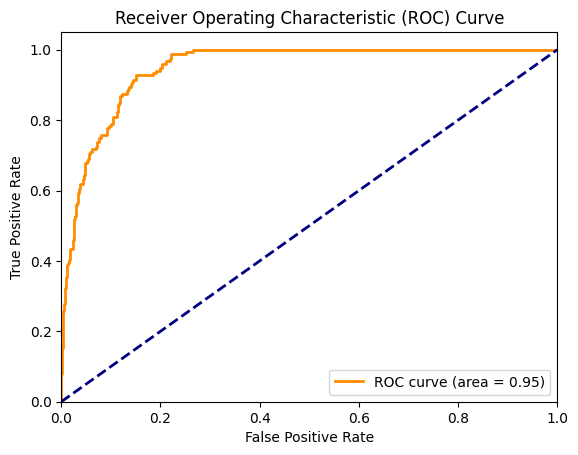

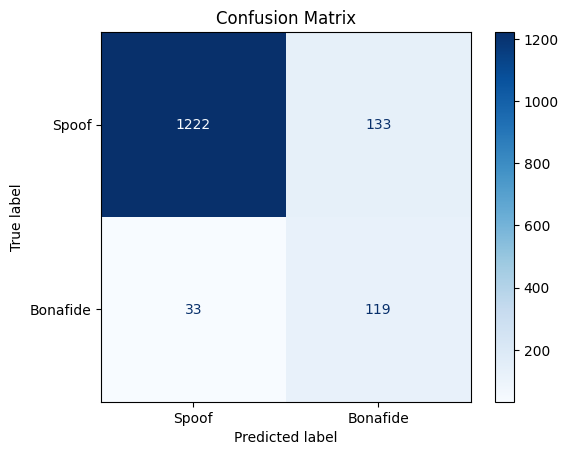

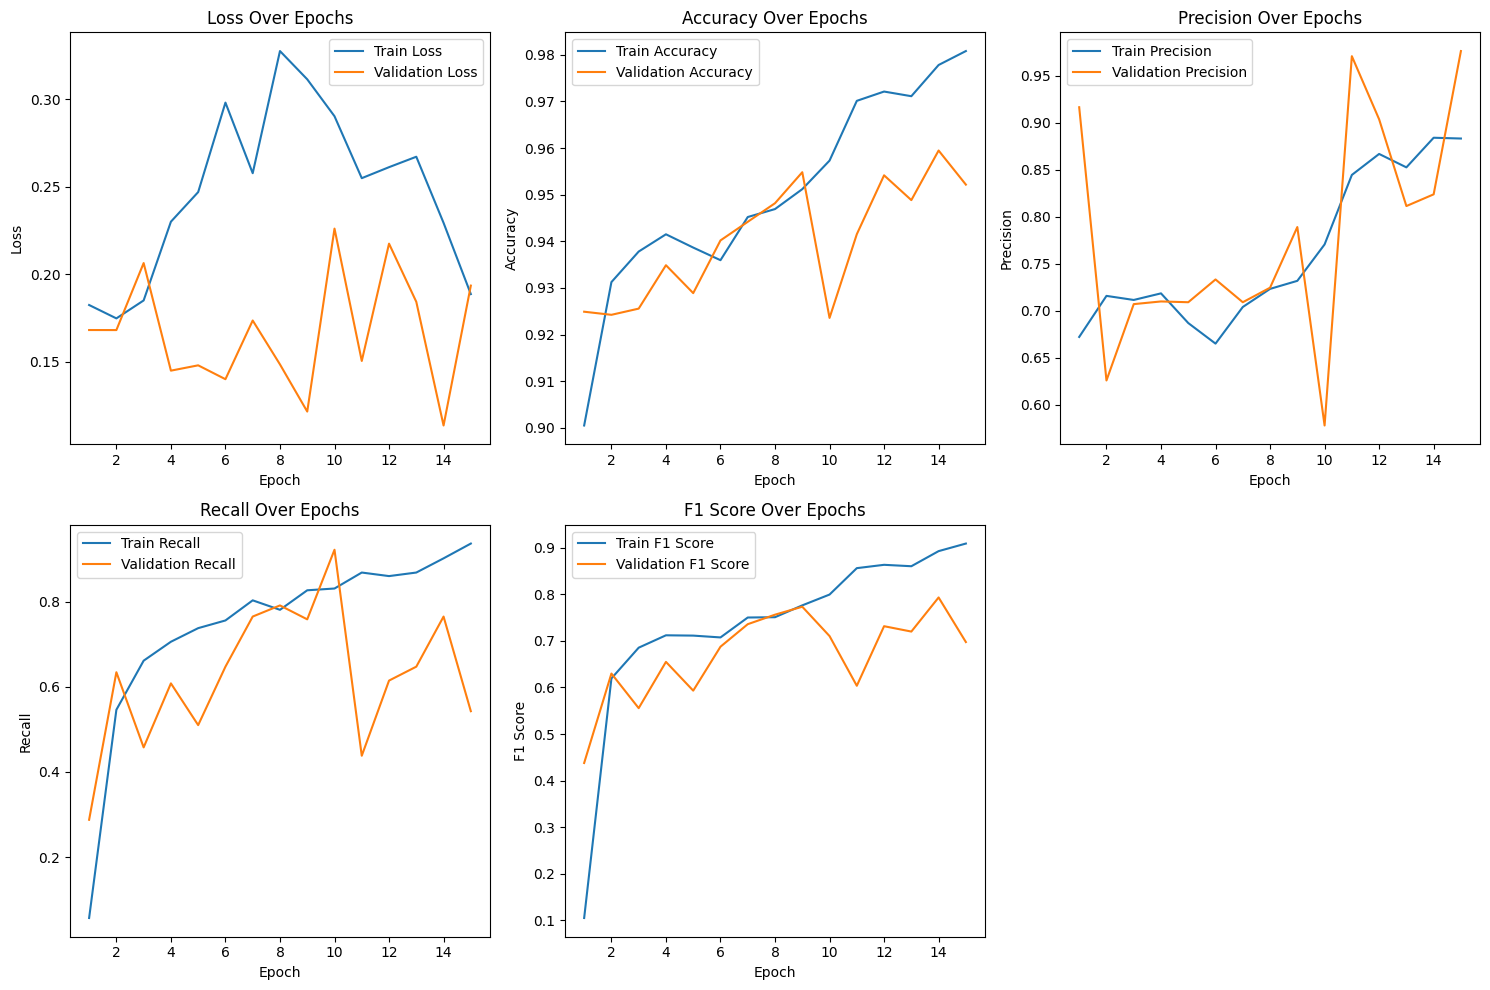

Sample 913: Prediction: Spoof, True Label: Bonafide, Correct: False
Sample 1285: Prediction: Bonafide, True Label: Bonafide, Correct: True
Sample 1123: Prediction: Bonafide, True Label: Bonafide, Correct: True
Sample 671: Prediction: Bonafide, True Label: Bonafide, Correct: True
Sample 1387: Prediction: Bonafide, True Label: Bonafide, Correct: True
Sample 1356: Prediction: Bonafide, True Label: Bonafide, Correct: True
Sample 823: Prediction: Bonafide, True Label: Bonafide, Correct: True
Sample 1465: Prediction: Bonafide, True Label: Bonafide, Correct: True
Sample 214: Prediction: Bonafide, True Label: Bonafide, Correct: True
Sample 731: Prediction: Bonafide, True Label: Bonafide, Correct: True
Sample 1129: Prediction: Bonafide, True Label: Bonafide, Correct: True
Sample 874: Prediction: Bonafide, True Label: Bonafide, Correct: True
Sample 1001: Prediction: Bonafide, True Label: Bonafide, Correct: True
Sample 1279: Prediction: Bonafide, True Label: Bonafide, Correct: True
Sample 1126: P

In [ ]:
# Define paths
save_path = "/content/drive/MyDrive/MENG/Deep Learning/Project/Checkpoints/"
metrics_file = os.path.join(save_path, "metrics_history.pt")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the best model checkpoint for evaluation
best_model_files = sorted(glob.glob(os.path.join(save_path, "best_model_checkpoint_epoch_*.pt")), key=os.path.getmtime)
if best_model_files:
    best_model_checkpoint = best_model_files[-1]
    best_checkpoint = torch.load(best_model_checkpoint, map_location=device)
    model = FusionModel(
        mfcc_dim=13, cqcc_dim=60, pitch_dim=1, energy_dim=1, embedding_dim=1024
    ).to(device)
    model.load_state_dict(best_checkpoint['model_state_dict'])
    print(f"Loaded best model from epoch {best_checkpoint['epoch']+1} with validation loss {best_checkpoint['best_val_loss']:.4f}")
else:
    print("No best model checkpoint found.")
    model = None

# Load full metrics history for all epochs
if os.path.exists(metrics_file):
    metrics_history = torch.load(metrics_file)['metrics']
    print("Loaded metrics history.")
else:
    print("No metrics history found.")
    metrics_history = None

# Evaluation function
def evaluate_model(model, test_loader):
    model.eval()
    all_preds, all_labels, all_outputs = [], [], []

    with torch.no_grad():
        for batch in test_loader:
            mfcc, cqcc, pitch, energy, embedding, labels = [
                batch[key].to(device) for key in ["mfcc", "cqcc", "pitch", "energy", "embedding", "label"]
            ]
            mfcc_mask = torch.ones((mfcc.size(0), mfcc.size(2)), dtype=torch.float32).to(device)
            cqcc_mask = torch.ones((cqcc.size(0), cqcc.size(2)), dtype=torch.float32).to(device)
            pitch_mask = torch.ones((pitch.size(0), pitch.size(2)), dtype=torch.float32).to(device)
            energy_mask = torch.ones((energy.size(0), energy.size(2)), dtype=torch.float32).to(device)

            outputs = model(mfcc, cqcc, pitch, energy, embedding, mfcc_mask, cqcc_mask, pitch_mask, energy_mask)
            predictions = (torch.sigmoid(outputs) > 0.5).float()

            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_outputs.extend(outputs.cpu().numpy())

    # Calculate evaluation metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)

    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Test Precision: {precision:.4f}")
    print(f"Test Recall: {recall:.4f}")
    print(f"Test F1 Score: {f1:.4f}")

    # Generate ROC Curve
    fpr, tpr, _ = roc_curve(all_labels, all_outputs)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (area = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.legend(loc="lower right")
    plt.show()

    # Generate Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Spoof", "Bonafide"])  # Corrected order
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.show()

# Visualize Metrics History
def plot_metrics_history(metrics_history):
    if not metrics_history:
        print("No metrics history to plot.")
        return

    epochs = range(1, len(metrics_history['loss']) + 1)  # Adjust epochs to start from 1

    plt.figure(figsize=(15, 10))

    # Plot Loss
    plt.subplot(2, 3, 1)
    plt.plot(epochs, metrics_history['loss'], label="Train Loss")
    plt.plot(epochs, metrics_history['val_loss'], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Over Epochs")
    plt.legend()

    # Plot Accuracy
    plt.subplot(2, 3, 2)
    plt.plot(epochs, metrics_history['accuracy'], label="Train Accuracy")
    plt.plot(epochs, metrics_history['val_accuracy'], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy Over Epochs")
    plt.legend()

    # Plot Precision
    plt.subplot(2, 3, 3)
    plt.plot(epochs, metrics_history['precision'], label="Train Precision")
    plt.plot(epochs, metrics_history['val_precision'], label="Validation Precision")
    plt.xlabel("Epoch")
    plt.ylabel("Precision")
    plt.title("Precision Over Epochs")
    plt.legend()

    # Plot Recall
    plt.subplot(2, 3, 4)
    plt.plot(epochs, metrics_history['recall'], label="Train Recall")
    plt.plot(epochs, metrics_history['val_recall'], label="Validation Recall")
    plt.xlabel("Epoch")
    plt.ylabel("Recall")
    plt.title("Recall Over Epochs")
    plt.legend()

    # Plot F1 Score
    plt.subplot(2, 3, 5)
    plt.plot(epochs, metrics_history['f1'], label="Train F1 Score")
    plt.plot(epochs, metrics_history['val_f1'], label="Validation F1 Score")
    plt.xlabel("Epoch")
    plt.ylabel("F1 Score")
    plt.title("F1 Score Over Epochs")
    plt.legend()

    plt.tight_layout()
    plt.show()


# Single Prediction on Random Test Samples
def predict_random_samples(model, test_loader, num_samples=16):
    model.eval()
    samples = random.sample(range(len(test_loader.dataset)), num_samples)
    correct_preds = 0

    with torch.no_grad():
        for idx in samples:
            sample = test_loader.dataset[idx]
            mfcc, cqcc, pitch, energy, embedding, label = (
                sample["mfcc"], sample["cqcc"], sample["pitch"],
                sample["energy"], sample["embedding"], sample["label"]
            )
            mfcc, cqcc, pitch, energy, embedding = (
                mfcc.to(device), cqcc.to(device), pitch.to(device),
                energy.to(device), embedding.to(device)
            )
            mfcc_mask = torch.ones((1, mfcc.size(1)), dtype=torch.float32).to(device)
            cqcc_mask = torch.ones((1, cqcc.size(1)), dtype=torch.float32).to(device)
            pitch_mask = torch.ones((1, pitch.size(1)), dtype=torch.float32).to(device)
            energy_mask = torch.ones((1, energy.size(1)), dtype=torch.float32).to(device)

            # Model prediction
            output = model(mfcc.unsqueeze(0), cqcc.unsqueeze(0), pitch.unsqueeze(0), energy.unsqueeze(0), embedding.unsqueeze(0), mfcc_mask, cqcc_mask, pitch_mask, energy_mask)
            prediction = (torch.sigmoid(output) > 0.5).item()

            # Compare prediction with true label
            is_correct = prediction == label.item()
            correct_preds += is_correct
            print(f"Sample {idx + 1}: Prediction: {'Spoof' if prediction else 'Bonafide'}, True Label: {'Spoof' if label.item() else 'Bonafide'}, Correct: {is_correct}")

    print(f"\nCorrect Predictions: {correct_preds}/{num_samples}")

# Load your test data
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=True)

# Run Evaluation
if model:
    evaluate_model(model, test_loader)
    plot_metrics_history(metrics_history)
    predict_random_samples(model, test_loader, num_samples=16)
else:
    print("Evaluation skipped due to missing model.")


<ipython-input-8-43614e0b0fef>:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_checkpoint = torch.load(best_model_checkpoint, map_location=device)


Loaded best model from epoch 14 with validation loss 0.1135
EER: 15.87% (Threshold: -3.0576)


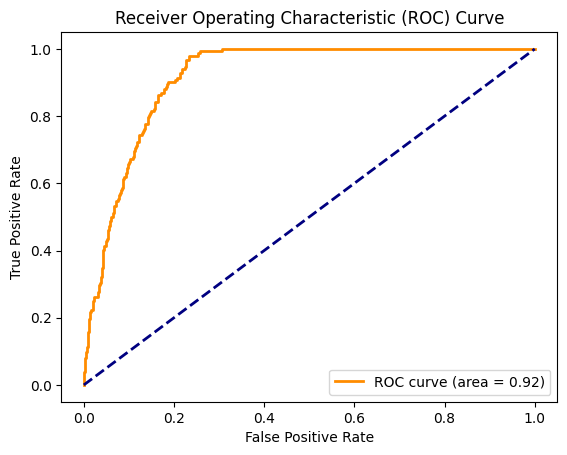

Final EER: 15.87%


In [ ]:
# Define paths
save_path = "/content/drive/MyDrive/MENG/Deep Learning/Project/Checkpoints/"
cm_scores_file = os.path.join(save_path, "cm_scores.txt")  # Path to save CM scores
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the best model checkpoint for evaluation
best_model_files = sorted(glob.glob(os.path.join(save_path, "best_model_checkpoint_epoch_*.pt")), key=os.path.getmtime)
if best_model_files:
    best_model_checkpoint = best_model_files[-1]
    best_checkpoint = torch.load(best_model_checkpoint, map_location=device)
    model = FusionModel(
        mfcc_dim=13, cqcc_dim=60, pitch_dim=1, energy_dim=1, embedding_dim=1024
    ).to(device)
    model.load_state_dict(best_checkpoint['model_state_dict'])
    print(f"Loaded best model from epoch {best_checkpoint['epoch'] + 1} with validation loss {best_checkpoint['best_val_loss']:.4f}")
else:
    print("No best model checkpoint found.")
    model = None


# Evaluation function with CM score generation and EER calculation
def evaluate_model_with_cm_scores(model, test_loader, cm_scores_file):
    model.eval()
    all_outputs = []
    all_labels = []
    sample_ids = []  # Store sample_ids for each trial

    with open(cm_scores_file, "w") as score_file:
        score_file.write("SAMPLE_ID   Key    CM SCORE\n")  # Header for CM scores file

        with torch.no_grad():
            for batch in test_loader:
                # Fetch data from batch
                mfcc, cqcc, pitch, energy, embedding, labels, sample_ids_batch = (
                    batch["mfcc"].to(device),
                    batch["cqcc"].to(device),
                    batch["pitch"].to(device),
                    batch["energy"].to(device),
                    batch["embedding"].to(device),
                    batch["label"].to(device),
                    batch["sample_id"],  # Now directly use 'sample_id'
                )

                # Precompute masks
                mfcc_mask = torch.ones_like(mfcc, dtype=torch.float32, device=device).mean(dim=-1)
                cqcc_mask = torch.ones_like(cqcc, dtype=torch.float32, device=device).mean(dim=-1)
                pitch_mask = torch.ones_like(pitch, dtype=torch.float32, device=device).mean(dim=-1)
                energy_mask = torch.ones_like(energy, dtype=torch.float32, device=device).mean(dim=-1)

                # Get model predictions
                outputs = model(mfcc, cqcc, pitch, energy, embedding, mfcc_mask, cqcc_mask, pitch_mask, energy_mask)
                all_outputs.append(outputs)
                all_labels.append(labels)
                sample_ids.extend(sample_ids_batch)

                # Save scores for each sample
                for i, score in enumerate(outputs):
                    score_value = score.item()
                    key = "bonafide" if labels[i].item() == 1 else "spoof"
                    score_file.write(f"{sample_ids_batch[i]} {key} {score_value:.6f}\n")

    # Concatenate outputs and labels
    all_outputs = torch.cat(all_outputs).cpu()
    all_labels = torch.cat(all_labels).cpu()

    # Compute EER
    fpr, tpr, thresholds = roc_curve(all_labels.numpy(), all_outputs.numpy())
    eer_threshold = thresholds[np.nanargmin(np.abs(fpr - (1 - tpr)))]
    eer = fpr[np.nanargmin(np.abs(fpr - (1 - tpr)))]
    print(f"EER: {eer * 100:.2f}% (Threshold: {eer_threshold:.4f})")

    # Plot ROC curve
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (area = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.legend(loc="lower right")
    plt.show()

    return eer

# Run evaluation with CM score generation
if model:
    cm_scores_file = os.path.join(save_path, "cm_scores.txt")
    eer = evaluate_model_with_cm_scores(model, test_loader, cm_scores_file)
    print(f"Final EER: {eer * 100:.2f}%")
else:
    print("Evaluation skipped due to missing model.")


#Evaluate the model and Create the CM Scores

<ipython-input-8-a3e9d6b2519f>:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_checkpoint = torch.load(best_model_checkpoint, map_location=device)


Loaded best model from epoch 14 with validation loss 0.1135
EER: 15.87% (Threshold: -3.0576)


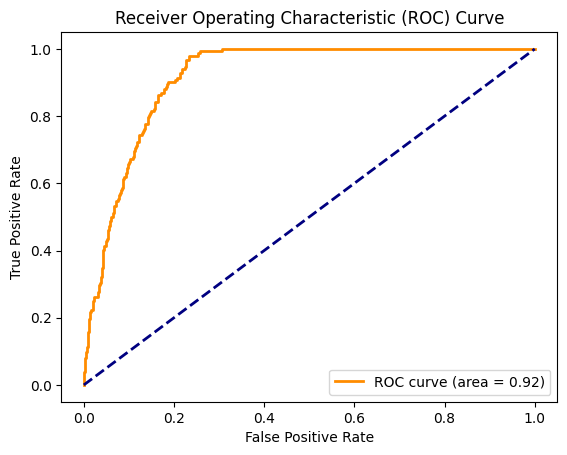

Final EER: 15.87%


In [ ]:
# Define paths
model_path = "/content/drive/MyDrive/MENG/Deep Learning/Project/Checkpoints/"
save_path = "/content/drive/MyDrive/MENG/Deep Learning/Project/Fixed_length_frame_processed/"
cm_scores_file = os.path.join(save_path, "cm_scores.txt")  # Path to save CM scores
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the best model checkpoint for evaluation
best_model_files = sorted(glob.glob(os.path.join(model_path, "best_model_checkpoint_epoch_*.pt")), key=os.path.getmtime)
if best_model_files:
    best_model_checkpoint = best_model_files[-1]
    best_checkpoint = torch.load(best_model_checkpoint, map_location=device)
    model = FusionModel(
        mfcc_dim=13, cqcc_dim=60, pitch_dim=1, energy_dim=1, embedding_dim=1024
    ).to(device)
    model.load_state_dict(best_checkpoint['model_state_dict'])
    print(f"Loaded best model from epoch {best_checkpoint['epoch'] + 1} with validation loss {best_checkpoint['best_val_loss']:.4f}")
else:
    print("No best model checkpoint found.")
    model = None


# Evaluation function with CM score generation and EER calculation
def evaluate_model_with_cm_scores(model, test_loader, cm_scores_file):
    model.eval()
    all_outputs = []
    all_labels = []
    sample_ids = []  # Store sample_ids for each trial

    with open(cm_scores_file, "w") as score_file:
        with torch.no_grad():
            for batch in test_loader:
                # Fetch data from batch
                mfcc, cqcc, pitch, energy, embedding, labels, sample_ids_batch = (
                    batch["mfcc"].to(device),
                    batch["cqcc"].to(device),
                    batch["pitch"].to(device),
                    batch["energy"].to(device),
                    batch["embedding"].to(device),
                    batch["label"].to(device),
                    batch["sample_id"],  # Now directly use 'sample_id'
                )

                # Precompute masks (on GPU for better performance)
                mfcc_mask = torch.ones_like(mfcc, dtype=torch.float32, device=device).mean(dim=-1)
                cqcc_mask = torch.ones_like(cqcc, dtype=torch.float32, device=device).mean(dim=-1)
                pitch_mask = torch.ones_like(pitch, dtype=torch.float32, device=device).mean(dim=-1)
                energy_mask = torch.ones_like(energy, dtype=torch.float32, device=device).mean(dim=-1)

                # Get model predictions
                outputs = model(mfcc, cqcc, pitch, energy, embedding, mfcc_mask, cqcc_mask, pitch_mask, energy_mask)
                all_outputs.append(outputs)
                all_labels.append(labels)
                sample_ids.extend(sample_ids_batch)

                # Save scores for each sample
                for i, score in enumerate(outputs):
                    score_value = score.item()
                    key = "bonafide" if labels[i].item() == 1 else "spoof"
                    score_file.write(f"{sample_ids_batch[i]} {key} {score_value:.6f}\n")

    # Concatenate outputs and labels
    all_outputs = torch.cat(all_outputs).cpu()
    all_labels = torch.cat(all_labels).cpu()

    # Compute EER
    fpr, tpr, thresholds = roc_curve(all_labels.numpy(), all_outputs.numpy())
    eer_threshold = thresholds[np.nanargmin(np.abs(fpr - (1 - tpr)))]
    eer = fpr[np.nanargmin(np.abs(fpr - (1 - tpr)))]
    print(f"EER: {eer * 100:.2f}% (Threshold: {eer_threshold:.4f})")

    # Plot ROC curve
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (area = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.legend(loc="lower right")
    plt.show()

    return eer

# Run evaluation with CM score generation
if model:
    cm_scores_file = os.path.join(save_path, "cm_scores.txt")
    eer = evaluate_model_with_cm_scores(model, test_loader, cm_scores_file)
    print(f"Final EER: {eer * 100:.2f}%")
else:
    print("Evaluation skipped due to missing model.")

#Combine data for eer and t-dcf analysis

In [ ]:
import pandas as pd

# File paths
cm_scores_path = "/content/drive/MyDrive/MENG/Deep Learning/Project/Fixed_length_frame_processed/cm_scores.txt"
eval_protocol_path = "/content/drive/MyDrive/MENG/Deep Learning/Project/Fixed_length_frame_processed/ASVspoof2019.LA.asv.eval.gi.trl.txt"
asv_scores_path = "/content/drive/MyDrive/MENG/Deep Learning/Project/Fixed_length_frame_processed/ASVspoof2019.LA.asv.eval.gi.trl.scores.txt"

# Step 1: Load CM scores
# Structure: SAMPLE_ID, KEY, CM_SCORE
cm_scores = []
with open(cm_scores_path, "r") as file:
    for line in file:
        parts = line.strip().split()
        cm_scores.append({
            "SAMPLE_ID": parts[0],
            "KEY": parts[1],
            "CM_SCORE": float(parts[2])
        })
cm_scores_df = pd.DataFrame(cm_scores)
print("CM scores loaded successfully.")
print(cm_scores_df.head())
print(f"Number of CM scores loaded: {len(cm_scores_df)}")

# Step 2: Load eval protocol
# Structure: CLAIMED_SPEAKER_ID, SAMPLE_ID, ATTACK_ID, TRIAL_KEY
eval_protocol = []
with open(eval_protocol_path, "r") as file:
    for line in file:
        parts = line.strip().split()
        eval_protocol.append({
            "CLAIMED_SPEAKER_ID": parts[0],
            "SAMPLE_ID": parts[1],
            "ATTACK_ID": parts[2],
            "TRIAL_KEY": parts[3]
        })
eval_protocol_df = pd.DataFrame(eval_protocol)
print("Eval protocol loaded successfully.")
print(eval_protocol_df.head())
print(f"Number of entries in eval protocol: {len(eval_protocol_df)}")

# Step 3: Filter eval protocol for rows matching SAMPLE_IDs in CM scores
# Deduplicate based on SAMPLE_ID to ensure one-to-one correspondence
filtered_eval_protocol_df = eval_protocol_df[eval_protocol_df["SAMPLE_ID"].isin(cm_scores_df["SAMPLE_ID"])]
deduplicated_eval_protocol_df = filtered_eval_protocol_df.drop_duplicates(subset="SAMPLE_ID")
print(f"Number of deduplicated protocol entries: {len(deduplicated_eval_protocol_df)}")

# Step 4: Validate alignment between CM scores and protocol
if len(deduplicated_eval_protocol_df) != len(cm_scores_df):
    raise ValueError(
        f"Mismatch after deduplication! Protocol: {len(deduplicated_eval_protocol_df)}, CM scores: {len(cm_scores_df)}"
    )

# Step 5: Load ASV scores
# Structure: ATTACK_ID, TRIAL_KEY, ASV_SCORE
asv_scores = []
with open(asv_scores_path, "r") as file:
    for line in file:
        parts = line.strip().split()
        asv_scores.append({
            "ATTACK_ID": parts[0],
            "TRIAL_KEY": parts[1],
            "ASV_SCORE": float(parts[2])
        })
asv_scores_df = pd.DataFrame(asv_scores)
print("ASV scores loaded successfully.")
print(asv_scores_df.head())
print(f"Number of entries in ASV scores: {len(asv_scores_df)}")

# Step 6: Filter ASV scores using protocol indices
protocol_indices = deduplicated_eval_protocol_df.index.tolist()
filtered_asv_scores_df = asv_scores_df.iloc[protocol_indices]
print(f"Number of filtered ASV scores: {len(filtered_asv_scores_df)}")

# Step 7: Merge all data into a single DataFrame
final_df = deduplicated_eval_protocol_df.copy()
final_df["CM_SCORE"] = cm_scores_df["CM_SCORE"].values  # Add CM scores
final_df["KEY_CM"] = cm_scores_df["KEY"].values         # Add CM keys
final_df["ASV_SCORE"] = filtered_asv_scores_df["ASV_SCORE"].values  # Add ASV scores

print("Final merged DataFrame:")
print(final_df.head())

# Save the final combined DataFrame
output_path = "/content/drive/MyDrive/MENG/Deep Learning/Project/Fixed_length_frame_processed/final_combined_scores.csv"
final_df.to_csv(output_path, index=False, header=False)
print(f"Final combined scores saved to {output_path}")


CM scores loaded successfully.
      SAMPLE_ID       KEY   CM_SCORE
0  LA_E_8469141     spoof -17.654333
1  LA_E_3379393  bonafide  -1.891652
2  LA_E_5015729     spoof  -8.282321
3  LA_E_7503879     spoof -19.476187
4  LA_E_9155671     spoof -13.048625
Number of CM scores loaded: 1507
Eval protocol loaded successfully.
  CLAIMED_SPEAKER_ID     SAMPLE_ID ATTACK_ID TRIAL_KEY
0            LA_0015  LA_E_1103494  bonafide    target
1            LA_0015  LA_E_4861467  bonafide    target
2            LA_0015  LA_E_6229989  bonafide    target
3            LA_0015  LA_E_4483232  bonafide    target
4            LA_0015  LA_E_3110493  bonafide    target
Number of entries in eval protocol: 102579
Number of deduplicated protocol entries: 1507
ASV scores loaded successfully.
  ATTACK_ID TRIAL_KEY  ASV_SCORE
0  bonafide    target   7.981530
1  bonafide    target  22.408420
2  bonafide    target  25.735920
3  bonafide    target  26.003140
4  bonafide    target   3.467947
Number of entries in ASV score

#Calculate eer and t-dcf

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve

# File Path
final_combined_scores_path = "/content/drive/MyDrive/MENG/Deep Learning/Project/Fixed_length_frame_processed/final_combined_scores.csv"

# Load final combined scores file
columns = [
    "CLAIMED_SPEAKER_ID", "SAMPLE_ID", "ATTACK_ID", "TRIAL_KEY",
    "CM_SCORE", "KEY", "ASV_SCORE"
]

# Correctly read the CSV file as comma-separated
final_df = pd.read_csv(final_combined_scores_path, sep=",", names=columns)

# Add Attack Label: bonafide = 1, spoof = 0
final_df["ATTACK_LABEL"] = final_df["KEY"].apply(lambda x: 1 if x == "bonafide" else 0)

# Display loaded DataFrame
print("Loaded DataFrame:")
print(final_df.head())
print(f"Number of entries in combined scores: {len(final_df)}")

# ---- Step 1: Calculate EER ----
def compute_eer(y_true, y_score):
    """
    Calculate Equal Error Rate (EER).
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_score, pos_label=1)
    fnr = 1 - tpr  # False Negative Rate

    # Find the point where FPR == FNR
    eer_threshold = thresholds[np.nanargmin(np.absolute((fnr - fpr)))]
    eer = fpr[np.nanargmin(np.absolute((fnr - fpr)))]

    return eer, eer_threshold

# Compute EER
eer, eer_threshold = compute_eer(final_df["ATTACK_LABEL"], final_df["CM_SCORE"])
print(f"EER: {eer * 100:.2f}% (Threshold: {eer_threshold})")

# ---- Step 2: Calculate t-DCF ----
def compute_t_dcf(asv_scores, cm_scores, labels, p_target=0.95, p_non_target=0.03, p_spoof=0.02):
    """
    Calculate the normalized tandem Decision Cost Function (t-DCF).
    """
    # Application-specific costs
    c_miss = 1  # Cost of a miss
    c_fa_asv = 10  # Cost of a false accept by ASV
    c_fa_cm = 1  # Cost of a false accept by CM

    # Convert labels: 1 (bonafide), 0 (spoof)
    labels = np.array(labels)

    # ASV thresholds
    asv_threshold = np.percentile(asv_scores, 50)  # Median threshold

    # ASV decisions
    asv_decisions = asv_scores > asv_threshold

    # Compute probabilities
    p_miss_asv = np.mean((labels == 1) & (~asv_decisions))  # ASV misses genuine
    p_fa_asv = np.mean((labels == 0) & (asv_decisions))  # ASV falsely accepts spoof

    # CM decisions
    cm_threshold = np.percentile(cm_scores, 50)  # Median threshold
    cm_decisions = cm_scores > cm_threshold

    p_fa_cm = np.mean((labels == 0) & (cm_decisions))  # CM falsely accepts spoof

    # t-DCF numerator
    numerator = (
        p_target * c_miss * p_miss_asv
        + p_non_target * c_fa_asv * p_fa_asv
        + p_spoof * c_fa_cm * p_fa_cm
    )

    # t-DCF denominator
    denominator = (
        p_target * c_miss
        + p_non_target * c_fa_asv
        + p_spoof * c_fa_cm
    )

    t_dcf_norm = numerator / denominator

    return t_dcf_norm

# Compute t-DCF
t_dcf = compute_t_dcf(
    final_df["ASV_SCORE"].values,
    final_df["CM_SCORE"].values,
    final_df["ATTACK_LABEL"].values
)

print(f"t-DCF: {t_dcf:.4f}")


Loaded DataFrame:
  CLAIMED_SPEAKER_ID     SAMPLE_ID ATTACK_ID TRIAL_KEY   CM_SCORE       KEY  \
0            LA_0030  LA_E_4906680  bonafide    target -17.654333     spoof   
1            LA_0030  LA_E_7012733  bonafide    target  -1.891652  bonafide   
2            LA_0048  LA_E_7823436  bonafide    target  -8.282321     spoof   
3            LA_0048  LA_E_1890409  bonafide    target -19.476187     spoof   
4            LA_0048  LA_E_7321687  bonafide    target -13.048625     spoof   

   ASV_SCORE  ATTACK_LABEL  
0  46.245230             0  
1  34.807500             1  
2  -7.144522             0  
3   9.196690             0  
4  14.196950             0  
Number of entries in combined scores: 1507
EER: 15.87% (Threshold: -3.057598)
t-DCF: 0.1501
